In [1]:
from Functions import GenSBM2_core, Estimation, Estimation_dsbm, NMI
# from CASR.functions_core import *

import warnings
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import time
from sklearn.metrics.cluster import normalized_mutual_info_score

import pandas as pd

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
warnings.simplefilter('ignore')

# Dataset

Dataset can be found:
https://essd.copernicus.org/articles/13/357/2021/

In [4]:
import pandas as pd
import glob

files = [
    "Dataset/OpenSky/flightlist_20190101_20190131.csv.gz",
    "Dataset/OpenSky/flightlist_20190201_20190228.csv.gz",
    "Dataset/OpenSky/flightlist_20190301_20190331.csv.gz",
    "Dataset/OpenSky/flightlist_20190401_20190430.csv.gz",
    "Dataset/OpenSky/flightlist_20190501_20190531.csv.gz",
    "Dataset/OpenSky/flightlist_20190601_20190630.csv.gz",
    "Dataset/OpenSky/flightlist_20190701_20190731.csv.gz",
    "Dataset/OpenSky/flightlist_20190801_20190831.csv.gz",
    "Dataset/OpenSky/flightlist_20190901_20190930.csv.gz",
    "Dataset/OpenSky/flightlist_20191001_20191031.csv.gz",
    "Dataset/OpenSky/flightlist_20191101_20191130.csv.gz",
    "Dataset/OpenSky/flightlist_20191201_20191231.csv.gz"
]

dfs = [pd.read_csv(f, compression='gzip') for f in files]

df = pd.concat(dfs, ignore_index=True)

In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df2 = df.dropna(subset=['origin', 'destination', 'latitude_1', 'longitude_1',
                       'latitude_2', 'longitude_2'])

origin_coords = df2.groupby('origin')[['latitude_1', 'longitude_1']].mean()
dest_coords   = df2.groupby('destination')[['latitude_2', 'longitude_2']].mean()

dest_coords.columns = ['latitude', 'longitude']

coords = pd.concat([origin_coords, dest_coords]).groupby(level=0).mean()
coords = coords.to_dict('index')

# G_faculty = nx.Graph() # undirected
G = nx.DiGraph() # directed
for _, row in df2.iterrows():
    o, d = row['origin'], row['destination']
    if o != d:
        G.add_edge(o, d, weight=G[o][d]['weight'] + 1 if G.has_edge(o, d) else 1)

pos = {node: (coords[node]['longitude'], coords[node]['latitude']) 
       for node in G.nodes() if node in coords}

In [6]:
import numpy as np
print(G.number_of_edges())
print(G.number_of_nodes())
print(np.round(nx.density(G), 4))

801748
15439
0.0034


In [7]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df2 = df.dropna(subset=['origin', 'destination', 'latitude_1', 'longitude_1',
                       'latitude_2', 'longitude_2'])

origin_coords = df2.groupby('origin')[['latitude_1', 'longitude_1']].mean()
dest_coords   = df2.groupby('destination')[['latitude_2', 'longitude_2']].mean()

dest_coords.columns = ['latitude', 'longitude']

coords = pd.concat([origin_coords, dest_coords]).groupby(level=0).mean()
coords = coords.to_dict('index')

G2 = nx.Graph() # undirected
for _, row in df2.iterrows():
    o, d = row['origin'], row['destination']
    if o != d:
        G2.add_edge(o, d, weight=G2[o][d]['weight'] + 1 if G2.has_edge(o, d) else 1)

pos = {node: (coords[node]['longitude'], coords[node]['latitude']) 
       for node in G2.nodes() if node in coords}

In [8]:
import numpy as np
print(G2.number_of_edges())
print(G2.number_of_nodes())
print(np.round(nx.density(G2), 4))

613202
15439
0.0051


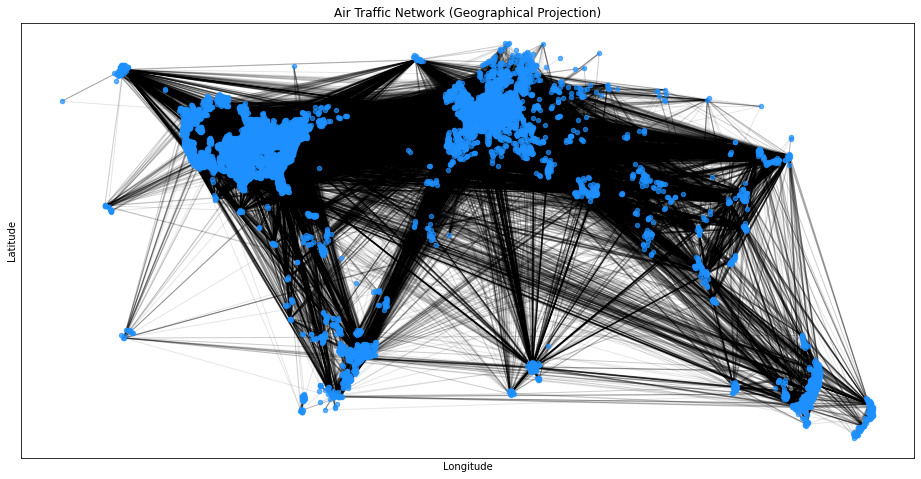

In [42]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

pos = {node: (coords[node]['longitude'], coords[node]['latitude']) 
       for node in G.nodes() if node in coords}


plt.figure(figsize=(16, 8))
nx.draw_networkx_nodes(G4, pos, node_size=20, node_color='dodgerblue', alpha=0.7)
nx.draw_networkx_edges(G4, pos, alpha=0.1, arrows=False)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Air Traffic Network (Geographical Projection)")
plt.show()

In [9]:
import numpy as np
import networkx as nx

A = nx.to_numpy_array(G, weight='weight', nodelist=sorted(G.nodes()))
# A = nx.to_numpy_array(G4, weight=None, nodelist=sorted(G4.nodes()))
A

print(A.shape)   # (n_nodes, n_nodes)
print(A[:5, :5])

(15439, 15439)
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [10]:
import numpy as np
import networkx as nx 

# A = nx.to_numpy_array(G4, weight='weight', nodelist=sorted(G4.nodes()))
A2_undir = nx.to_numpy_array(G2, weight=None, nodelist=sorted(G2.nodes()))
A2_undir

print(A2_undir.shape)   # (n_nodes, n_nodes)
print(A2_undir[:5, :5])

(15439, 15439)
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


# Chernoff Information

In [13]:
from scipy import sparse
import numpy as np

def estimate_block_probs_sparse(A, labels, K, directed=False):
    """
    Sparse-friendly version of block probability estimation.
    Works for both csr_matrix and dense ndarray.
    """
    if not sparse.issparse(A):
        A = sparse.csr_matrix(A)
    labels = np.asarray(labels)
    sizes = np.bincount(labels, minlength=K)
    P = np.zeros((K, K), dtype=float)

    # Use matrix multiplications for block sums
    # Construct one-hot membership matrix Z (n x K)
    n = len(labels)
    row_idx = np.arange(n)
    Z = sparse.csr_matrix((np.ones(n), (row_idx, labels)), shape=(n, K))

    # Block sum matrix: Z^T A Z
    block_sums = Z.T @ A @ Z  # (K x K) sparse matrix

    # Convert to dense
    block_sums = np.array(block_sums.todense())

    # Compute probabilities
    for a in range(K):
        for b in range(K):
            na, nb = sizes[a], sizes[b]
            if na == 0 or nb == 0:
                continue
            if not directed and a == b:
                possible = na * (na - 1) / 2
            else:
                possible = na * nb
            P[a, b] = block_sums[a, b] / possible

    return P, sizes

In [14]:
def compute_Q(Z, B):
    """Compute probability matrix Q = Z B Z^T"""
    return Z @ B @ Z.T

def compute_H(Q):
    """Compute expected value of AA: H = Q Q"""
    # return Q @ Q
    return Q @ Q/len(Q)

def estimate_B_hat(H, Z, K):
    """
    Estimate block matrix B_hat using matrix H and cluster indicator Z.
    Works for both label vectors (n,) and one-hot matrices (n, K).
    """
    Z = np.array(Z)
    
    # If Z is one-hot (n, K), convert it to label vector
    if Z.ndim == 2:
        labels = np.argmax(Z, axis=1)
    else:
        labels = Z

    B_hat = np.zeros((K, K))
    for i in range(K):
        for j in range(K):
            mask_i = (labels == i)
            mask_j = (labels == j)
            block = H[np.ix_(mask_i, mask_j)]
            if block.size > 0:
                B_hat[i, j] = np.mean(block)

    return B_hat

def compute_V(Q):
    N = Q.shape[0]
    V = np.zeros((N, N))
    for i in range(N):
        # q_vec for all j at once: q_vec[k,j] = Q[i,k] * Q[k,j]
        q_mat = Q[i, :, None] * Q  # (N,1)*(N,N) -> (N,N), rows=k, cols=j
        # sum over k
        V[i, :] = (q_mat * (1 - q_mat)).sum(axis=0) / (N**2)
    return V

def estimate_C_hat(V, Z, K):
    """
    Estimate blockwise variance C_hat from V.
    V: variance matrix (N x N)
    Z: node labels (N,) or one-hot (N x K)
    K: number of clusters
    Returns:
        C_hat of shape (K, K)
    """

    Z = np.array(Z)

    if Z.ndim == 2:
        labels = np.argmax(Z, axis=1)
    else:
        labels = Z

    C_hat = np.zeros((K, K))
    for i in range(K):
        for j in range(K):
            mask_i = (labels == i)
            mask_j = (labels == j)
            block = V[np.ix_(mask_i, mask_j)]
            if block.size > 0:
                C_hat[i, j] = np.mean(block)

    return C_hat


import numpy as np
from scipy.optimize import minimize_scalar

def Chernoff_information_size_adjusted(B, C, pi, K, eps=1e-9):
    chernoff = []
    I = np.eye(K)
    Pi = np.diag(pi)
    
    for k in range(K):
        for l in range(K):
            if k != l:
                e = (I[k] - I[l]).reshape(K, 1)

                def f(t):
                    if t <= 0 or t >= 1:
                        return -np.inf
                    S_kl = (1 - t) * np.diag(C[k,:]) + t * np.diag(C[l,:])
                    try:
                        val = float(e.T @ B @ Pi @ np.linalg.inv(S_kl) @ B @ e)
                    except np.linalg.LinAlgError:
                        return -np.inf
                    return 0.5 * t * (1 - t) * val

                res = minimize_scalar(lambda tt: -f(tt), bounds=(eps, 1-eps), method="bounded")
                sup_val = f(res.x)

#                 print(f"(k={k}, l={l}) sup at t={res.x:.4f} → {sup_val:.6f}")

                chernoff.append(sup_val)
    
    ci = [val for val in chernoff if val > 0]
    return min(ci)

def Chernoff_C_ASE(B):
    K = len(B)
    C = np.zeros((K, K))
    for i in range(K):
        for j in range(K):
            p = B[i,j]
            C[i,j] = p * (1-p)

    return C

In [15]:
def chernoff_information_results(A, k, d, rs, direction, method):
    
    score_ase = []
    score_dase = []

    progress_bar = tqdm(total=rs, desc="Processing")
    
    for i in range(rs):

        pipeline = Estimation_dsbm.ClusteringPipeline(A)

        # ASE
        ase = pipeline.gen_ASE(case='ASE1', k=k, d=d, rs=i, direction = direction, method=method)
        P_ase, sizes_ase = estimate_block_probs_sparse(A, ase, K=k, directed=direction)

        pi_ase = sizes_ase/np.sum(sizes_ase)
        
        B_ase = P_ase
        C_ase = Chernoff_C_ASE(B_ase)
        CI_ase = Chernoff_information_size_adjusted(B_ase, C_ase, pi_ase, k)
        score_ase.append(CI_ase)
        
        # DASE
        dase = pipeline.gen_ASE(case='Atilde', k=k, d=d, rs=i, direction = direction, method=method)
        P_dase, sizes_dase = estimate_block_probs_sparse(A, dase, K=k, directed=direction)

        pi_dase = sizes_dase/np.sum(sizes_dase)

        N = len(dase)
        Z = np.zeros((N, k), dtype=int)
        Z[np.arange(N), dase] = 1
        
        Q = compute_Q(Z, P_dase)
        H = compute_H(Q)
        B_dase = estimate_B_hat(H, dase, k)
        V = compute_V(Q)
        C_dase = estimate_C_hat(V, dase, k)
        
        CI_dase = Chernoff_information_size_adjusted(B_dase, C_dase, pi_dase, k)
        score_dase.append(CI_dase)

        progress_bar.update(1)
        
    progress_bar.close()
    print("Processing completed.")
    

    return (
    np.mean(score_ase), np.mean(score_dase),
    np.std(score_ase), np.std(score_dase)
)

## K=2

### ASE

In [ ]:
# K-Means

k=2; d=4
direction=False
method = 'K-Means'

CI_ase_kmeans_k2 = []
ratio_ase_kmeans_k2 = np.zeros((30, k))

progress_bar = tqdm(total=30, desc="Processing")

for rs in range(30):

    pipeline_ase = Estimation_dsbm.ClusteringPipeline(A2_undir)
    ase_kmeans = pipeline_ase.gen_ASE(case='ASE1', k=k, d=d, rs=rs, direction = direction, method=method)

    P_ase_kmeans, sizes_ase_kmeans = estimate_block_probs_sparse(A2_undir, ase_kmeans, K=k, directed=direction)

    pi_ase_kmeans = sizes_ase_kmeans/np.sum(sizes_ase_kmeans)
    ratio_ase_kmeans_k2[rs, :] = np.sort(pi_ase_kmeans)

    B_ase_kmeans = P_ase_kmeans
    C_ase_kmeans = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            p = B_ase_kmeans[i,j]
            C_ase_kmeans[i,j] = p * (1-p)

    # B_ase_kmeans = P_ase_kmeans
    # C_ase_kmeans = Chernoff_C_ASE(B_ase_kmeans)
    
    CI_ase_kmeans = Chernoff_information_size_adjusted(B_ase_kmeans, C_ase_kmeans, pi_ase_kmeans, k)

    CI_ase_kmeans_k2.append(CI_ase_kmeans) 

    progress_bar.update(1)

progress_bar.close()
print("Processing completed.")
print("")
print(np.round(np.mean(CI_ase_kmeans_k2),4))
print(np.round(np.std(CI_ase_kmeans_k2),2))

In [ ]:
# K-Means

k=2; d=4
direction=False
method = 'K-Means'

CI_ase_gmm_k2 = []
ratio_ase_gmm_k2 = np.zeros((30, k))

progress_bar = tqdm(total=30, desc="Processing")

for rs in range(30):

    pipeline_ase = Estimation_dsbm.ClusteringPipeline(A2_undir)
    ase_gmm = pipeline_ase.gen_ASE(case='ASE1', k=k, d=d, rs=rs, direction = direction, method=method)

    P_ase_gmm, sizes_ase_gmm = estimate_block_probs_sparse(A2_undir, ase_gmm, K=k, directed=direction)

    pi_ase_gmm = sizes_ase_gmm/np.sum(sizes_ase_gmm)
    ratio_ase_gmm_k2[rs, :] = np.sort(pi_ase_gmm)

    B_ase_gmm = P_ase_gmm
    C_ase_gmm = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            p = B_ase_gmm[i,j]
            C_ase_gmm[i,j] = p * (1-p)

    # B_ase_gmm = P_ase_gmm
    # C_ase_gmm = Chernoff_C_ASE(B_ase_gmm)
    
    CI_ase_gmm = Chernoff_information_size_adjusted(B_ase_gmm, C_ase_gmm, pi_ase_gmm, k)

    CI_ase_gmm_k2.append(CI_ase_gmm) 

    progress_bar.update(1)

progress_bar.close()
print("Processing completed.")
print("")
print(np.round(np.mean(CI_ase_gmm_k2),4))
print(np.round(np.std(CI_ase_gmm_k2),2))

### DASE

In [ ]:
# K=2, kmeans

k=2; d=4
direction=False
method = 'K-Means'

CI_dase_kmeans_k2 = []

progress_bar = tqdm(total=30, desc="Processing")

for rs in range(30):

    pipeline_dase = Estimation_dsbm.ClusteringPipeline(A2_undir)
    dase_kmeans = pipeline_dase.gen_ASE(case='Atilde', k=k, d=d, rs=rs, direction = direction, method=method)

    P_dase_kmeans, sizes_dase_kmeans = estimate_block_probs_sparse(A2_undir, dase_kmeans, K=k, directed=direction)
    pi_dase_kmeans = sizes_dase_kmeans/np.sum(sizes_dase_kmeans)

    N = len(dase_kmeans)
    Z = np.zeros((N, k), dtype=int)
    Z[np.arange(N), dase_kmeans] = 1

    Q = compute_Q(Z, P_dase_kmeans)
    H = compute_H(Q)
    B_dase_kmeans = estimate_B_hat(H, dase_kmeans, k)
    V = compute_V2_fast(Q)
    C_dase_kmeans = estimate_C_hat(V, dase_kmeans, k)
    
    CI_dase_kmeans = Chernoff_information_size_adjusted(B_dase_kmeans, C_dase_kmeans, pi_dase_kmeans, k)

    CI_dase_kmeans_k2.append(CI_dase_kmeans)

    progress_bar.update(1)

progress_bar.close()
print("Processing completed.")
print("")
print(CI_dase_kmeans_k2)

In [ ]:
# K=2, GMM

k=2; d=4
direction=False
method = 'GMM'

CI_dase_gmm_k2 = []

progress_bar = tqdm(total=30, desc="Processing")

for rs in range(30):

    pipeline_dase = Estimation_dsbm.ClusteringPipeline(A2_undir)
    dase_gmm = pipeline_dase.gen_ASE(case='Atilde', k=k, d=d, rs=rs, direction = direction, method=method)

    P_dase_gmm, sizes_dase_gmm = estimate_block_probs_sparse(A2_undir, dase_gmm, K=k, directed=direction)
    pi_dase_gmm = sizes_dase_gmm/np.sum(sizes_dase_gmm)

    N = len(dase_gmm)
    Z = np.zeros((N, k), dtype=int)
    Z[np.arange(N), dase_gmm] = 1

    Q = compute_Q(Z, P_dase_gmm)
    H = compute_H(Q)
    B_dase_gmm = estimate_B_hat(H, dase_gmm, k)
    V = compute_V2_fast(Q)
    C_dase_gmm = estimate_C_hat(V, dase_gmm, k)
    
    CI_dase_gmm = Chernoff_information_size_adjusted(B_dase_gmm, C_dase_gmm, pi_dase_gmm, k)

    CI_dase_gmm_k2.append(CI_dase_gmm)

    progress_bar.update(1)

progress_bar.close()
print("Processing completed.")
print("")
print(CI_dase_gmm_k2)

### Table

In [22]:
import pandas as pd

data = {
    "Metric": ["ASE", "DASE"],
    "K-Means (k=2)": [
        f"{CI_ase_kmeans_k2:.4f} ({std_ase_kmeans_k2:.2f})",
        f"{CI_dase_kmeans_k2:.4f} ({std_dase_kmeans_k2:.2f})"
    ],
    "GMM (k=2)": [
        f"{CI_ase_gmm_k2:.4f} ({std_ase_gmm_k2:.2f})",
        f"{CI_dase_gmm_k2:.4f} ({std_dase_gmm_k2:.2f})"
    ]
}

df = pd.DataFrame(data)
df

,Metric,K-Means (k=2),GMM (k=2)
0,ASE,0.0454 (0.00),0.0059 (0.00)
1,DASE,16.5460 (0.00),1.6531 (0.00)


## K=6

### ASE

In [ ]:
# K-Means

k=6; d=4
direction=False
method = 'K-Means'

CI_ase_kmeans_k6 = []
ratio_ase_kmeans_k6 = np.zeros((30, k))

progress_bar = tqdm(total=30, desc="Processing")

for rs in range(30):

    pipeline_ase = Estimation_dsbm.ClusteringPipeline(A2_undir)
    ase_kmeans = pipeline_ase.gen_ASE(case='ASE1', k=k, d=d, rs=rs, direction = direction, method=method)

    P_ase_kmeans, sizes_ase_kmeans = estimate_block_probs_sparse(A2_undir, ase_kmeans, K=k, directed=direction)

    pi_ase_kmeans = sizes_ase_kmeans/np.sum(sizes_ase_kmeans)
    ratio_ase_kmeans_k6[rs, :] = np.sort(pi_ase_kmeans)

    B_ase_kmeans = P_ase_kmeans
    C_ase_kmeans = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            p = B_ase_kmeans[i,j]
            C_ase_kmeans[i,j] = p * (1-p)

    # B_ase_kmeans = P_ase_kmeans
    # C_ase_kmeans = Chernoff_C_ASE(B_ase_kmeans)
    
    CI_ase_kmeans = Chernoff_information_size_adjusted(B_ase_kmeans, C_ase_kmeans, pi_ase_kmeans, k)

    CI_ase_kmeans_k6.append(CI_ase_kmeans) 

    progress_bar.update(1)

progress_bar.close()
print("Processing completed.")
print("")
print(np.round(np.mean(CI_ase_kmeans_k6),4))
print(np.round(np.std(CI_ase_kmeans_k6),2))

In [ ]:
# K-Means

k=6; d=4
direction=False
method = 'GMM'

CI_ase_gmm_k6 = []
ratio_ase_gmm_k6 = np.zeros((30, k))

progress_bar = tqdm(total=30, desc="Processing")

for rs in range(30):

    pipeline_ase = Estimation_dsbm.ClusteringPipeline(A2_undir)
    ase_gmm = pipeline_ase.gen_ASE(case='ASE1', k=k, d=d, rs=rs, direction = direction, method=method)

    P_ase_gmm, sizes_ase_gmm = estimate_block_probs_sparse(A2_undir, ase_gmm, K=k, directed=direction)

    pi_ase_gmm = sizes_ase_gmm/np.sum(sizes_ase_gmm)
    ratio_ase_gmm_k6[rs, :] = np.sort(pi_ase_gmm)

    B_ase_gmm = P_ase_gmm
    C_ase_gmm = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            p = B_ase_gmm[i,j]
            C_ase_gmm[i,j] = p * (1-p)

    # B_ase_gmm = P_ase_gmm
    # C_ase_gmm = Chernoff_C_ASE(B_ase_gmm)
    
    CI_ase_gmm = Chernoff_information_size_adjusted(B_ase_gmm, C_ase_gmm, pi_ase_gmm, k)

    CI_ase_gmm_k6.append(CI_ase_gmm) 

    progress_bar.update(1)

progress_bar.close()
print("Processing completed.")
print("")
print(np.round(np.mean(CI_ase_gmm_k6),4))
print(np.round(np.std(CI_ase_gmm_k6),2))

### DASE

In [ ]:
# K=6, kmeans

k=6; d=4
direction=False
method = 'K-Means'

CI_dase_kmeans_k6 = []

progress_bar = tqdm(total=30, desc="Processing")

for rs in range(30):

    pipeline_dase = Estimation_dsbm.ClusteringPipeline(A2_undir)
    dase_kmeans = pipeline_dase.gen_ASE(case='Atilde', k=k, d=d, rs=rs, direction = direction, method=method)

    P_dase_kmeans, sizes_dase_kmeans = estimate_block_probs_sparse(A2_undir, dase_kmeans, K=k, directed=direction)
    pi_dase_kmeans = sizes_dase_kmeans/np.sum(sizes_dase_kmeans)

    N = len(dase_kmeans)
    Z = np.zeros((N, k), dtype=int)
    Z[np.arange(N), dase_kmeans] = 1

    Q = compute_Q(Z, P_dase_kmeans)
    H = compute_H(Q)
    B_dase_kmeans = estimate_B_hat(H, dase_kmeans, k)
    V = compute_V2_fast(Q)
    C_dase_kmeans = estimate_C_hat(V, dase_kmeans, k)
    
    CI_dase_kmeans = Chernoff_information_size_adjusted(B_dase_kmeans, C_dase_kmeans, pi_dase_kmeans, k)

    CI_dase_kmeans_k6.append(CI_dase_kmeans)

    progress_bar.update(1)

progress_bar.close()
print("Processing completed.")
print("")
print(CI_dase_kmeans_k6)

In [ ]:
# K=2, gmm

k=6; d=4
direction=False
method = 'GMM'

CI_dase_gmm_k6 = []

progress_bar = tqdm(total=30, desc="Processing")

for rs in range(30):

    pipeline_dase = Estimation_dsbm.ClusteringPipeline(A2_undir)
    dase_gmm = pipeline_dase.gen_ASE(case='Atilde', k=k, d=d, rs=rs, direction = direction, method=method)

    P_dase_gmm, sizes_dase_gmm = estimate_block_probs_sparse(A2_undir, dase_gmm, K=k, directed=direction)
    pi_dase_gmm = sizes_dase_gmm/np.sum(sizes_dase_gmm)

    N = len(dase_gmm)
    Z = np.zeros((N, k), dtype=int)
    Z[np.arange(N), dase_gmm] = 1

    Q = compute_Q(Z, P_dase_gmm)
    H = compute_H(Q)
    B_dase_gmm = estimate_B_hat(H, dase_gmm, k)
    V = compute_V2_fast(Q)
    C_dase_gmm = estimate_C_hat(V, dase_gmm, k)
    
    CI_dase_gmm = Chernoff_information_size_adjusted(B_dase_gmm, C_dase_gmm, pi_dase_gmm, k)

    CI_dase_gmm_k6.append(CI_dase_gmm)

    progress_bar.update(1)

progress_bar.close()
print("Processing completed.")
print("")
print(CI_dase_gmm_k6)

### Table

In [18]:
import pandas as pd

data = {
    "Metric": ["ASE", "DASE"],
    "K-Means (k=2)": [
        f"{CI_ase_kmeans_k6:.4f} ({std_ase_kmeans_k6:.2f})",
        f"{CI_dase_kmeans_k6:.4f} ({std_dase_kmeans_k6:.2f})"
    ],
    "GMM (k=2)": [
        f"{CI_ase_gmm_k6:.4f} ({std_ase_gmm_k6:.2f})",
        f"{CI_dase_gmm_k6:.4f} ({std_dase_gmm_k6:.2f})"
    ]
}

df = pd.DataFrame(data)
df

,Metric,K-Means (k=2),GMM (k=2)
0,ASE,0.0013 (0.00),0.0006 (0.00)
1,DASE,0.5396 (0.21),0.0537 (0.01)


In [ ]:
# K-Means

k=4; d=4
direction=True
method = 'K-Means'

CI_ase_kmeans_k4 = []
ratio_ase_kmeans_k4 = np.zeros((30, k))

progress_bar = tqdm(total=30, desc="Processing")

for rs in range(30):

    pipeline_ase = Estimation_dsbm.ClusteringPipeline(A2)
    ase_kmeans = pipeline_ase.gen_ASE(case='ASE1', k=k, d=d, rs=rs, direction = direction, method=method)

    P_ase_kmeans, sizes_ase_kmeans = estimate_block_probs_sparse(A2, ase_kmeans, K=4, directed=True)

    pi_ase_kmeans = sizes_ase_kmeans/np.sum(sizes_ase_kmeans)
    ratio_ase_kmeans_k4[rs, :] = np.sort(pi_ase_kmeans)

    B_ase_kmeans = P_ase_kmeans
    C_ase_kmeans = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            p = B_ase_kmeans[i,j]
            C_ase_kmeans[i,j] = p * (1-p)

    # B_ase_kmeans = P_ase_kmeans
    # C_ase_kmeans = Chernoff_C_ASE(B_ase_kmeans)
    
    CI_ase_kmeans = Chernoff_information_size_adjusted(B_ase_kmeans, C_ase_kmeans, pi_ase_kmeans, 4)

    CI_ase_kmeans_k4.append(CI_ase_kmeans)

    progress_bar.update(1)

progress_bar.close()


In [33]:
K = 4
N = len(dase_kmeans)
Z = np.zeros((N, K), dtype=int)
Z[np.arange(N), dase_kmeans] = 1

 
Q_kmeans = compute_Q(Z, P_dase_kmeans)
print("Q_kmeans")
H_kmeans = compute_H(Q_kmeans)
print("H_kmeans")
B_dase_kmeans = estimate_B_hat(H_kmeans, dase_kmeans, K)
print("B_dase_kmeans")
V_kmeans = compute_V2_fast(Q_kmeans)
print("V_kmeans")
C_dase_kmeans = estimate_C_hat(V_kmeans, dase_kmeans, K)
print("C_dase_kmeans")

Q_gmm
H_gmm
B_dase_gmm
V_gmm
C_dase_gmm


In [34]:
pi_dase_kmeans = sizes_dase_kmeans/np.sum(sizes_dase_kmeans)

CI_dase_kmeans = Chernoff_information_size_adjusted(B_dase_kmeans, C_dase_kmeans, pi_dase_kmeans, 4)
np.round(CI_dase_kmeans, 4)

14.3239

In [36]:
K = 4
pi_ase2_kmeans = sizes_ase2_kmeans/np.sum(sizes_ase2_kmeans)

B_ase2_kmeans = P_ase2_kmeans
C_ase2_kmeans = np.zeros((K, K))
for i in range(K):
    for j in range(K):
        p = B_ase2_kmeans[i,j]
        C_ase2_kmeans[i,j] = p * (1-p)

CI_ase2_kmeans = Chernoff_information_size_adjusted(B_ase2_kmeans, C_ase2_kmeans, pi_ase2_kmeans, 4)
np.round(CI_ase2_kmeans, 4)

0.0009

In [33]:
K = 4
N = len(dase2_kmeans)
Z = np.zeros((N, K), dtype=int)
Z[np.arange(N), dase2_kmeans] = 1

 
Q2_kmeans = compute_Q(Z, P_dase2_kmeans)
print("Q_kmeans")
H2_kmeans = compute_H(Q2_kmeans)
print("H_kmeans")
B2_dase_kmeans = estimate_B_hat(H2_kmeans, dase2_kmeans, K)
print("B_dase_kmeans")
V2_kmeans = compute_V2_fast(Q2_kmeans)
print("V_kmeans")
C2_dase_kmeans = estimate_C_hat(V2_kmeans, dase2_kmeans, K)
print("C_dase_kmeans")

pi_dase2_kmeans = sizes_dase2_kmeans/np.sum(sizes_dase2_kmeans)

CI_dase2_kmeans = Chernoff_information_size_adjusted(B2_dase_kmeans, C2_dase_kmeans, pi_dase2_kmeans, 4)
np.round(CI_dase2_kmeans, 4)

NameError: name 'P_dase2_gmm' is not defined

In [18]:
# K-Means

k=4; d=4
direction=True
method = 'K-Means'

CI_ase_kmeans_k4 = []
ratio_ase_kmeans_k4 = np.zeros((30, k))

progress_bar = tqdm(total=30, desc="Processing")

for rs in range(30):

    pipeline_ase = Estimation_dsbm.ClusteringPipeline(A2)
    ase_kmeans = pipeline_ase.gen_ASE(case='ASE1', k=k, d=d, rs=rs, direction = direction, method=method)

    P_ase_kmeans, sizes_ase_kmeans = estimate_block_probs_sparse(A2, ase_kmeans, K=4, directed=True)

    pi_ase_kmeans = sizes_ase_kmeans/np.sum(sizes_ase_kmeans)
    ratio_ase_kmeans_k4[rs, :] = np.sort(pi_ase_kmeans)

    B_ase_kmeans = P_ase_kmeans
    C_ase_kmeans = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            p = B_ase_kmeans[i,j]
            C_ase_kmeans[i,j] = p * (1-p)

    # B_ase_kmeans = P_ase_kmeans
    # C_ase_kmeans = Chernoff_C_ASE(B_ase_kmeans)
    
    CI_ase_kmeans = Chernoff_information_size_adjusted(B_ase_kmeans, C_ase_kmeans, pi_ase_kmeans, 4)

    CI_ase_kmeans_k4.append(CI_ase_kmeans)

    progress_bar.update(1)

progress_bar.close()
print("Processing completed.")

Processing:   0%|          | 0/30 [00:00<?, ?it/s]

Processing completed.


In [19]:
print(np.mean(CI_ase_kmeans_k4))
print(np.std(CI_ase_kmeans_k4))

0.003596441023501764
0.0005256479594612821


In [20]:
ratio_ase_kmeans_k4.mean(axis=0)

array([0.01425395, 0.01964074, 0.03151974, 0.93458557])

In [30]:
# K-Means

k=4; d=4
direction=True
method = 'K-Means'

CI_dase_kmeans_k4 = []
ratio_dase_kmeans_k4 = np.zeros((30, k))

progress_bar = tqdm(total=10, desc="Processing")

for rs in range(10):

    pipeline_dase = Estimation_dsbm.ClusteringPipeline(A2)
    dase_kmeans = pipeline_dase.gen_ASE(case='Atilde', k=k, d=d, rs=rs, direction = direction, method=method)

    P_dase_kmeans, sizes_dase_kmeans = estimate_block_probs_sparse(A, dase_kmeans, K=4, directed=True)

    pi_dase_kmeans = sizes_dase_kmeans/np.sum(sizes_dase_kmeans)
    ratio_dase_kmeans_k4[rs, :] = pi_dase_kmeans

    N = len(dase_kmeans)
    Z = np.zeros((N, k), dtype=int)
    Z[np.arange(N), dase_kmeans] = 1

    Q = compute_Q(Z, P_dase_kmeans)
    H = compute_H(Q)
    B_dase_kmeans = estimate_B_hat(H, dase_kmeans, k)
    V = compute_V2_fast(Q)
    C_dase_kmeans = estimate_C_hat(V, dase_kmeans, k)
    
    CI_dase_kmeans = Chernoff_information_size_adjusted(B_dase_kmeans, C_dase_kmeans, pi_dase_kmeans, 4)

    CI_dase_kmeans_k4.append(CI_dase_kmeans)

    progress_bar.update(1)

progress_bar.close()
print("Processing completed.")

Processing:   0%|          | 0/10 [00:00<?, ?it/s]

Processing completed.


In [33]:
pipeline_dase = Estimation_dsbm.ClusteringPipeline(A2)
dase_kmeans = pipeline_dase.gen_ASE(case='Atilde', k=k, d=d, rs=0, direction = direction, method=method)

P_dase_kmeans, sizes_dase_kmeans = estimate_block_probs_sparse(A2, dase_kmeans, K=4, directed=True)
print(P_dase_kmeans)

pi_dase_kmeans = sizes_dase_kmeans/np.sum(sizes_dase_kmeans)
# ratio_dase_kmeans_k4[rs, :] = pi_dase_kmeans

N = len(dase_kmeans)
Z = np.zeros((N, k), dtype=int)
Z[np.arange(N), dase_kmeans] = 1

Q = compute_Q(Z, P_dase_kmeans)
H = compute_H(Q)
print(H)
# B_dase_kmeans = estimate_B_hat(H, dase_kmeans, k)
# print(B_dase_kmeans)
# V = compute_V2_fast(Q)
# C_dase_kmeans = estimate_C_hat(V, dase_kmeans, k)

[[0.4540955  0.05038628 0.00566911 0.00927612]
 [0.05232375 0.6477902  0.21591299 0.02654307]
 [0.00344034 0.1583256  0.04614741 0.00445635]
 [0.00543308 0.01480792 0.00338333 0.00094594]]
[[9.68050218e-06 9.68050218e-06 9.68050218e-06 ... 9.68050218e-06
  9.68050218e-06 9.68050218e-06]
 [9.68050218e-06 9.68050218e-06 9.68050218e-06 ... 9.68050218e-06
  9.68050218e-06 9.68050218e-06]
 [9.68050218e-06 9.68050218e-06 9.68050218e-06 ... 9.68050218e-06
  9.68050218e-06 9.68050218e-06]
 ...
 [9.68050218e-06 9.68050218e-06 9.68050218e-06 ... 9.68050218e-06
  9.68050218e-06 9.68050218e-06]
 [9.68050218e-06 9.68050218e-06 9.68050218e-06 ... 9.68050218e-06
  9.68050218e-06 9.68050218e-06]
 [9.68050218e-06 9.68050218e-06 9.68050218e-06 ... 9.68050218e-06
  9.68050218e-06 9.68050218e-06]]


In [34]:
B_dase_kmeans = estimate_B_hat(H, dase_kmeans, k)
print(B_dase_kmeans)

[[4.28480421e-03 1.21246716e-03 2.85725397e-04 1.18175580e-04]
 [1.24581623e-03 1.01980178e-02 3.23997551e-03 3.99534647e-04]
 [2.06622439e-04 2.37504637e-03 7.61039619e-04 9.18990191e-05]
 [6.88263480e-05 2.22867404e-04 7.00182487e-05 9.68050218e-06]]


In [35]:
V = compute_V2_fast(Q)
C_dase_kmeans = estimate_C_hat(V, dase_kmeans, k)

In [36]:
Chernoff_information_size_adjusted(B_dase_kmeans, C_dase_kmeans, pi_dase_kmeans, 4)

2.3159197688295924e-09

In [31]:
CI_dase_kmeans_k4

[3.1223917224362854e-08,
 2.2065952463168205e-08,
 2.932969557898228e-08,
 2.9067071470801076e-08,
 3.016998019170567e-08,
 2.1758709833657195e-08,
 0.0,
 0.0,
 2.9481907512194953e-08,
 3.1223917224362854e-08]

In [32]:
print(np.mean(CI_dase_kmeans_k4))
print(np.std(CI_dase_kmeans_k4))

2.2432115149923507e-08
1.167369729937991e-08


In [ ]:
# K-Means

k=4; d=4
direction=True
method = 'K-Means'

# CI_dase_kmeans_k4 = []
# ratio_dase_kmeans_k4 = np.zeros((30, k))

progress_bar = tqdm(total=10, desc="Processing")

for rs in range(10, 20):

    pipeline_dase = Estimation_dsbm.ClusteringPipeline(A2)
    dase_kmeans = pipeline_dase.gen_ASE(case='Atilde', k=k, d=d, rs=0, direction = direction, method=method)

    P_dase_kmeans, sizes_dase_kmeans = estimate_block_probs(A, dase_kmeans, K=4, directed=True)

    pi_dase_kmeans = sizes_dase_kmeans/np.sum(sizes_dase_kmeans)
    ratio_dase_kmeans_k4[rs, :] = pi_dase_kmeans

    N = len(dase_kmeans)
    Z = np.zeros((N, k), dtype=int)
    Z[np.arange(N), dase_kmeans] = 1

    Q = compute_Q(Z, P_dase_kmeans)
    H = compute_H(Q)
    B_dase_kmeans = estimate_B_hat(H, dase_kmeans, k)
    V = compute_V2_fast(Q)
    C_dase_kmeans = estimate_C_hat(V, dase_kmeans, k)
    
    CI_dase_kmeans = Chernoff_information_size_adjusted(B_dase_kmeans, C_dase_kmeans, pi_dase_kmeans, 4)

    CI_dase_kmeans_k4.append(CI_dase_kmeans)

    progress_bar.update(1)

progress_bar.close()
print("Processing completed.")

In [18]:
# K-Means

k=4; d=4
direction=True
method = 'kmeans'

CI_ase_kmeans_k4 = []
ratio_ase_kmeans_k4 = np.zeros((30, k))

progress_bar = tqdm(total=30, desc="Processing")

for rs in range(30):

    pipeline_ase = Estimation_dsbm.ClusteringPipeline(A2)
    ase_kmeans = pipeline_ase.gen_ASE(case='ASE1', k=k, d=d, rs=rs, direction = direction, method=method)

    P_ase_kmeans, sizes_ase_kmeans = estimate_block_probs_sparse(A2, ase_kmeans, K=4, directed=True)

    pi_ase_kmeans = sizes_ase_kmeans/np.sum(sizes_ase_kmeans)
    ratio_ase_kmeans_k4[rs, :] = np.sort(pi_ase_kmeans)

    B_ase_kmeans = P_ase_kmeans
    C_ase_kmeans = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            p = B_ase_kmeans[i,j]
            C_ase_kmeans[i,j] = p * (1-p)

    # B_ase_kmeans = P_ase_kmeans
    # C_ase_kmeans = Chernoff_C_ASE(B_ase_kmeans)
    
    CI_ase_kmeans = Chernoff_information_size_adjusted(B_ase_kmeans, C_ase_kmeans, pi_ase_kmeans, 4)

    CI_ase_kmeans_k4.append(CI_ase_kmeans)

    progress_bar.update(1)

progress_bar.close()
print("Processing completed.")

Processing:   0%|          | 0/30 [00:00<?, ?it/s]

Processing completed.


In [19]:
print(np.mean(CI_ase_kmeans_k4))
print(np.std(CI_ase_kmeans_k4))

0.0005539804563942496
9.228743718553703e-05


In [20]:
# K-Means

k=4; d=4
direction=False
method = 'kmeans'

CI_dase_kmeans_k4 = []
ratio_dase_kmeans_k4 = np.zeros((30, k))

progress_bar = tqdm(total=10, desc="Processing")

for rs in range(10):

    pipeline_dase = Estimation_dsbm.ClusteringPipeline(A2)
    dase_kmeans = pipeline_dase.gen_ASE(case='Atilde', k=k, d=d, rs=rs, direction = direction, method=method)

    P_dase_kmeans, sizes_dase_kmeans = estimate_block_probs_sparse(A2_undir, dase_kmeans, K=4, directed=False)

    pi_dase_kmeans = sizes_dase_kmeans/np.sum(sizes_dase_kmeans)
    ratio_dase_kmeans_k4[rs, :] = pi_dase_kmeans

    N = len(dase_kmeans)
    Z = np.zeros((N, k), dtype=int)
    Z[np.arange(N), dase_kmeans] = 1

    Q = compute_Q(Z, P_dase_kmeans)
    H = compute_H(Q)
    B_dase_kmeans = estimate_B_hat(H, dase_kmeans, k)
    V = compute_V2_fast(Q)
    C_dase_kmeans = estimate_C_hat(V, dase_kmeans, k)
    
    CI_dase_kmeans = Chernoff_information_size_adjusted(B_dase_kmeans, C_dase_kmeans, pi_dase_kmeans, 4)

    CI_dase_kmeans_k4.append(CI_dase_kmeans)

    progress_bar.update(1)

progress_bar.close()
print("Processing completed.")

Processing:   0%|          | 0/10 [00:00<?, ?it/s]

Processing completed.


In [21]:
print(np.mean(CI_dase_kmeans_k4))
print(np.std(CI_dase_kmeans_k4))

5.760427286054483e-09
5.614477639997332e-10
